# Day 4 (03 November 2025)
- Run `python`
- Write `import this`. Read.
```
The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!
```
- Reminder: I have written these notes for myself. I am familiar with the Java programming language. I may keep comparing Python with Java for easier grasp. You may find that useful if you have been a Java programmer. Of course, Python is not Java.
- I am starting with Python, from Mortelli et. al.
- I am learning it as an experienced programmer. I use PyCharm as my IDE. I want to learn it thoroughly.
- **Everything is an object in Python, unlike Java**. In Java, to quote Josh Bloch, we have a great divide: primitives vs. objects, and, although the so-called _boxed primitives_ blur the _chasm_ between them, they do not bury it; one has to be aware that a name may refer to a primitive value (e.g. 3 or 3.3) or an object (e.g. "Joe").
- Python REPL has two nice self-documenting features: 1) `dir`, and 2) `help`.
- Python is not strongly typed. A name that refers to a value of a given type can be reassigned to a value of another type in the same scope. - The executable `python` is both interpreter (relatively slowly interprets a Python source line) and compiler (directly converts a source code into object code for the target machine for faster execution). This is unlike a compiled language like Java which has two different executables: `javac` (the compiler) and `java` (the interpreter and ahead-of-time compiler for faster execution).

- You notice several methods that begin and end with `__` when you do something like `dir(2)`. They are called Dunder (special or magic) methods. Python achieves *operator overloading* via these methods that every object has access to.

Thus, if you implemented your own class with a _method_: `__add(self, other)__`, then two objects (instances) of your class can be "added" using the `+` operator; Python interpreter does the wiring: 
```
# Implement a class, Character, that models the basic unit that makes up strings; implement the dunder method __add__
a = Character('a')
b = Character('b')
w = c1 + c2 # w => "ab"
```

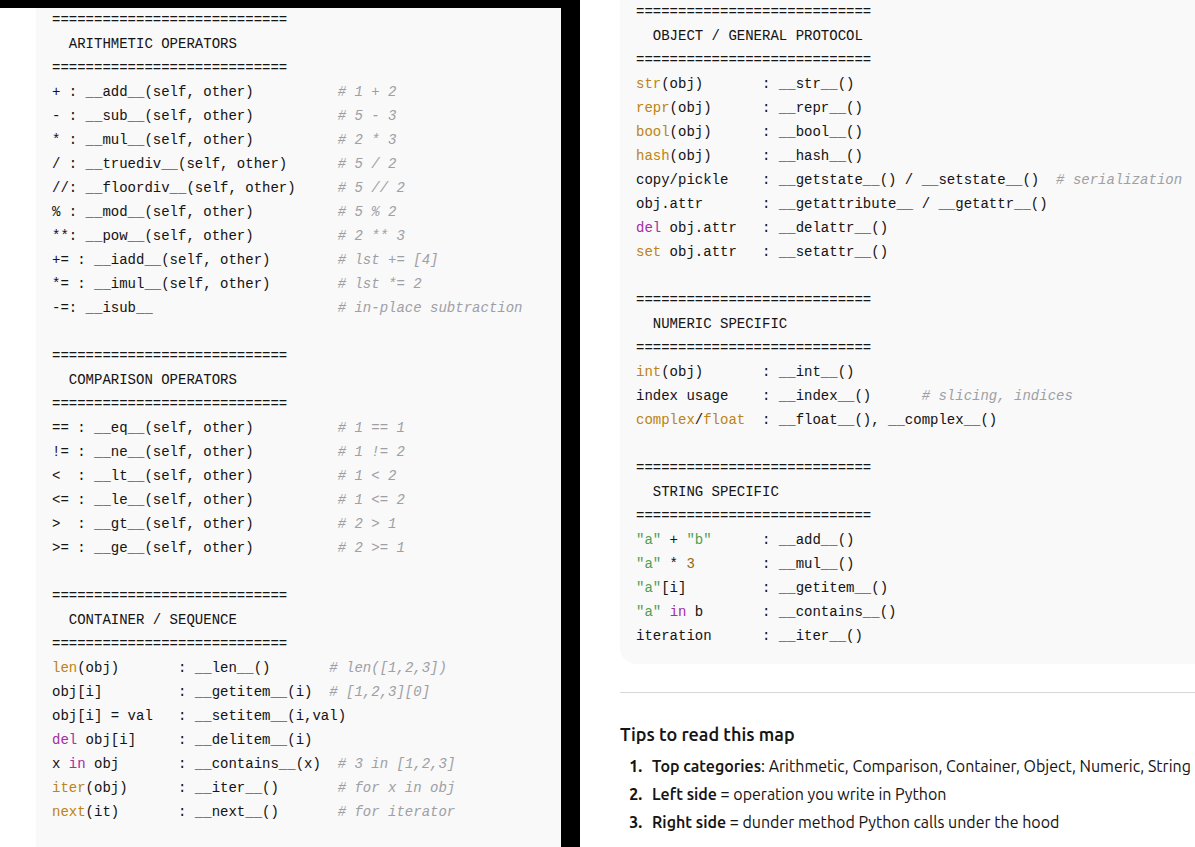


- Python objects have both regular methods and special methods. A class simply assumes a behavior by implementing special (dunder) methods like `__add__` or `__len__`. This is Guido's language designer preference that developers really like! 

- It supports duck-typing because of this. Java, otoh, needs Interfaces, sometimes, even *marker* interfaces.

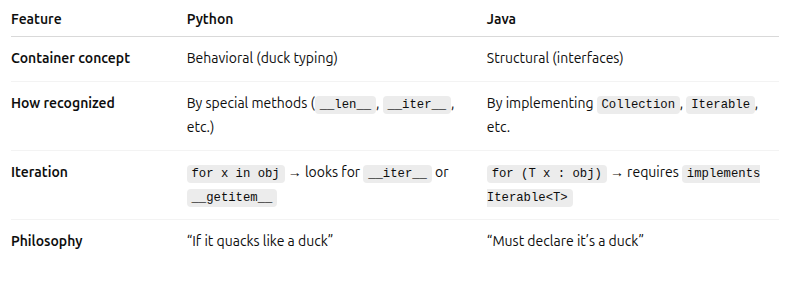

Let's start with the basic drill. This sounds like a drill, but, beneath the surface, it is fun. We have got to master tokens, statements, data types and operations on them, variables and references, expressions and operators.

### Tokens and Statements

- Python source file is a UTF-8-encoded text file. This file is interpreted by the `python` interpreter.
- The Interpreter also does some functions of a conventional compiler. It breaks each logical line into a sequence of elementary lexical components known as tokens. Each token corresponds to a substring of the logical line. The normal token types are identifiers, keywords, operators, delimiters, and literals.
- In Python, expressions compute, statements command; statements are _executed_. A Statement is either simple of compound: Python's grammar (`cpython/Python/Grammar/python.gram`) tells us the following about the "inside view":
```
# --- Statements ------------------------------------------------------

statement[stmt_ty]:
    compound_stmt
    | simple_stmts

simple_stmts[stmt_ty]:
    a=simple_stmt+ $a

simple_stmt[stmt_ty]:
    assignment
    | star_expressions
    | return_stmt
    | import_stmt
    | raise_stmt
    | 'pass'
    | del_stmt
    | yield_stmt
    | assert_stmt
    | 'break'
    | 'continue'
    | global_stmt
    | nonlocal_stmt

compound_stmt[stmt_ty]:
    function_def
    | if_stmt
    | class_def
    | with_stmt
    | for_stmt
    | try_stmt
    | while_stmt
    | match_stmt

```

### Data Types
- There are several builtin data types in Python. Here are a few of them. We will deal with operations on them shortly.
  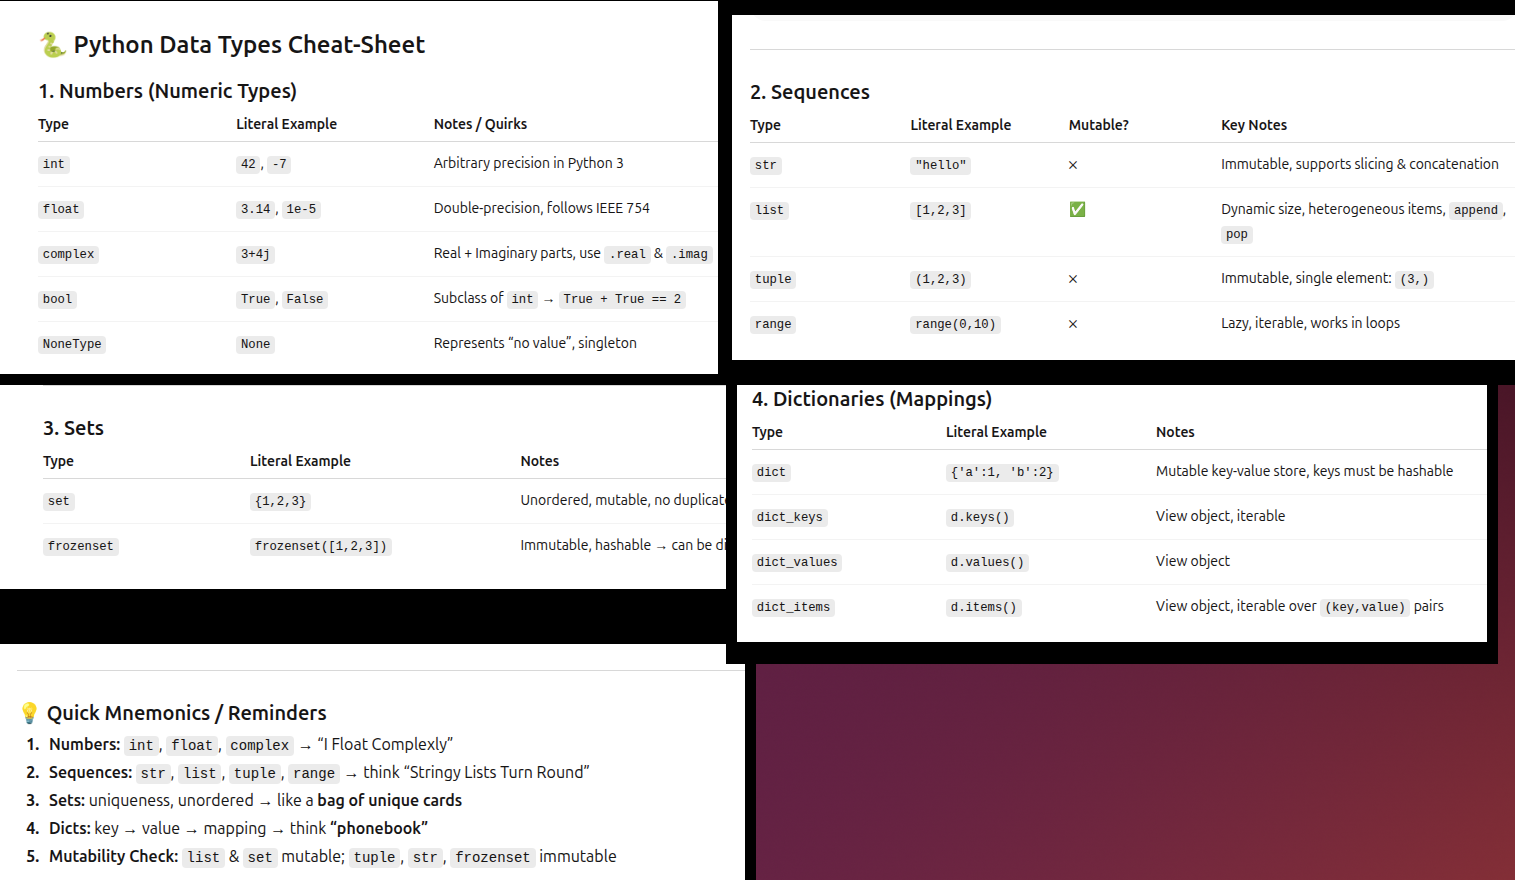

### Variables and Other References
- A Python program accesses data values through references. A reference is a "name" that refers to a value (object). References take the form of variables, attributes, and items. A variable or other reference **has no intrinsic type**. The object (value) to which a reference is _bound_ at a given time always has a type, but a given reference may be bound to objects of various types in the same _scope_:

In [1]:
a = 10
print(a)
a = "hello"
print(a)

10
hello


#### Variables

- Bind values to names (or variables) using the assignment statement.
- Rebind by reassignments.
- Unbind by the `del` statement.
- 

In [2]:
a = 10
print(a)
del(a)
print(a)

10


NameError: name 'a' is not defined

#### Object Attributes and Object Items
- This is an important characteristic.
- In Python, Objects have _attributes_ and they may have items.
- Attributes can be properties or methods (which are _callable_, i.e. methods can be _called_, properties can't be). They are accessed by the '.' operator: `<ref-name-or-value>.<attribute-name>`, e.g. `"moon".isupper()`.
- Python doesn't have a strong distinction between a callable attribute and a non-callable attribute.
- It's not exactly clear why "objects having items" is called out specifically in Martelli's book. Items make sense for _container objects_. Clearly, not every object contains other objects. Container objects implement a dunder (magic) method `__get_item__`. 
- You can get the items of a container object by the "subscript" operator: `[]`. For example, `x[y]` refers to the item at the key or index bound to name `y`, within the container object bound to name `x`. There is a related _slicing_ operation as well.
- An `int` is not a container:

In [3]:
x = 10
x[1]

TypeError: 'int' object is not subscriptable

- Python compiler catches several "compilation" errors before interpreting any byte-code. This process happens transparently as Python does not have a separate compiler executable (unlike Java). The output of the compilation process is the Python byte-code (usually in memory, or in `__pycache__` files: try `python -m py_compile file.py` and see the `__pycache__` folder; you can also try the `dis` module which _disassembles_ the mnemonics from its byte-code: `import dis`). If compiler succeeds, then, of course, you can never have any compilation errors. Only runtime errors may result.
- Compiler catches these errors:
1) True syntax errors (`SyntaxError: invalid syntax, expected ':', incomplete input`, etc.), 

In [4]:
if True print("hi")       # ❌ Missing colon

SyntaxError: invalid syntax (202132693.py, line 1)

In [5]:
def f(,x): pass           # ❌ Bad parameter list

SyntaxError: invalid syntax (2508974258.py, line 1)

In [6]:
for x in range(10)        # ❌ Missing colon

SyntaxError: expected ':' (95089802.py, line 1)

In [7]:
a = (1, 2,                # ❌ Unclosed parentheses

SyntaxError: incomplete input (7950014.py, line 1)

In [8]:
print("hi"                # ❌ Unterminated string literal


SyntaxError: incomplete input (3589083863.py, line 1)

In [9]:
x = 09                    # ❌ Invalid number literal

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3860261442.py, line 1)

2) Indentation Errors,

In [10]:
def f():
print("hi")    # ❌ unexpected indent / unindent


IndentationError: expected an indented block after function definition on line 1 (1039717598.py, line 2)

3) Tokenization Errors (caught by the lexer),

In [11]:
print('hi)

SyntaxError: unterminated string literal (detected at line 1) (3639009714.py, line 1)

4) Static semantic errors (e.g. `return` outside a function, assignment to literal: `1 = x` etc.).

Rest of the errors are runtime errors that can only be detected when the program runs.

### Assignment Statements

#### Plain Assignment
- General form: `target = expression`.
- This is mostly how one expects. One pleasant surprise is `a=b=c=0` which assigns 0 (`rvalue` is evaluated exactly once) to three different _targets_.
- There is one weird assignment called _unpacking assignment_ which unpacks the rvalues. Such things increase complexity, but apparently people sometimes accept (or even enjoy) them: `first, second, third = x` is equivalent to `first = x[0]`, `second = x[1]`, ` third = x[2]`. The `iterable` x must have _exactly_ three elements (since there are three targets). Perhaps Guido thought that such assignments are commonplace. It increases "line noise" (as DHH would put it) at the cost of complexity. It reminded me of several quotes about "getting used to": 1) Young man! In mathematics, you don't understand things, you just get used to them! -- John von Neumann 2) Everything is easy to use once you know how to use it -- Bill Shannon (an ex-colleague of mine).
- There is also a _starred target_ which I have seen in many places. This _unpacks_ in apparently an intuitive way. Guido wanted to pack more meaning in syntax hopefully at the cost of manageable complexity. My hypothesis is that beginners to a language have to just go by John von Neumann's directive above -- just get used to it; learning quirky language features may well be a part of learning it idiomatically. I like Crockford's take on it: "Language designers are (fallible) people like us. They may make design choices that are expensive in terms of cognition."  However, once you get used to it, do you care?
-  `first, *second, third = x` is equivalent to `first = x[0]`, `second = x[1]`, ` third = x[2]`, but now the _iterable_ `x` can have two or more elements and `second` is an _iterable_ itself: A world of difference the `*` makes!


In [12]:
first, *second, third=[1,2,3,4]
print(type(first), first)
print(type(second), second)
print(type(third), third)


<class 'int'> 1
<class 'list'> [2, 3]
<class 'int'> 4


#### Augmented Assignment
- Since the language supported operator overloading via the _dunder methods_, apparently more accepted complexity gets added to the language. For instance, if `a, b` are variables number type, in any imperative (non-functional) language, `a +=b` implies "`a` is _given_ a new value that equals the sum of the _current values_ of `a` and `b`". But Python can have a _flavor of some operations_ called an _in-place_ flavor!
- This is applicable only to mutable objects via a _dunder_ method called `__iadd__`.
- But for immutable types, you always get a variable reassigned. Consider, for example:

In [13]:
a = 2
a += 1

- This simply means `a` is _reassigned_ to 3 (which is what you expect); the `int` class never gets a dunder method named `__iadd__`. So far so procedural (that is, applicable to a non-functional language).
- But, if `a` is an instance of your class that supports in-place addition, your class can implement a dunder method `__iadd__` and then you have created a class instances of which can be mutable! Instances of your class now support "augmented assignment".
- Such an assignment: `a += b, a -= 2, n /= 10` is handy, but Python gives it a name that is mouthful: "Augmented" assignment!
- A design principle is "Make simple things easy and complex things possible." Of course such an augmented assignment is useful in practice in accordance with that principle.
- Remember, however, augmented assignment does not support multiple targets unlike plain assignments.

#### The `del` Statement
- This simply unbinds a name. I am not yet sure why it is needed, but maybe it is useful in reducing the scope of a name. Perhaps I will learn more uses later.
- Here is one case where `del` may be required. I think it is obscure:

In [14]:
# This code presents problems when you run the notebook cell. Restart the kernel afterword.
xs = list() # calls the global function: `list`
list = [1, 2] # shadows the global function: `list`
ys = list() # TypeError: 'list' object is not callable

TypeError: 'list' object is not callable

In [15]:
xs = list() # calls the global function: `list`
list = [1, 2] # shadows the global function: `list`
del list # delete the variable list, does not affect the global function
ys = list() # no problem, global function has now become accessible!
print(ys)

TypeError: 'list' object is not callable

### A Few Reminders
- No negativity, please!
- "You are here to learn the language and speak it like the natives (idiomatically). So, no criticism, **just get used to it**." -- you hear someone (perhaps your own inner voice) say.
- **Be positive. Seriously. I think I should consult Brett Slatkin's "Effective Python" from time-to-time. I have written to him. Hope he responds.**